# Underwater Mine Detection — Training Experiments

Three controlled comparisons, run on Kaggle (Tesla T4 GPU), using the
dataset prepared in `01_data_preparation.ipynb`:

- **Run 1**: YOLO11n, COCO-pretrained, full fine-tune (baseline)
- **Run 2**: YOLO11m, sonar-domain-pretrained (SONARINTEL), full fine-tune
- **Run 3**: YOLO11m, COCO-pretrained, full fine-tune (size-matched control)



In [1]:
%pip install ultralytics -q
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 4.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


## data.yaml path for Kaggle's read-only input mount

`/kaggle/input/` is read-only, so the yaml (which had a local relative
`path: .`) is copied to the writable `/kaggle/working/` directory and
edited to point at the correct absolute input path.

In [6]:
import yaml

data_yaml_content = {
    'path': '',#datasetpath within '' 
    'train': 'images/train',
    'val': 'images/val',
    'nc': 1,
    'names': ['mine'],
}

with open('/kaggle/working/data.yaml', 'w') as f:
    yaml.dump(data_yaml_content, f, default_flow_style=False)

# verify it's valid before training
with open('/kaggle/working/data.yaml', 'r') as f:
    print(f.read())

names:
- mine
nc: 1
path: /kaggle/input/datasets/tarunpandianm/umd-ssd/merged_dataset
train: images/train
val: images/val



In [7]:
with open('/kaggle/working/data.yaml', 'r') as f:
    print(f.read())


names:
- mine
nc: 1
path: /kaggle/input/datasets/tarunpandianm/umd-ssd/merged_dataset
train: images/train
val: images/val



### Augmentation is constrained by sonar physics throughout only transforms that preserve physically realistic acoustic shadow behavior are used (see config comments below).

In [8]:
DATA_YAML = '/kaggle/working/data.yaml'

AUGMENTATION_CONFIG = dict(
    fliplr=0.5,        # horizontal flip — physically valid (across-track)
    flipud=0.0,         # vertical flip disabled — breaks shadow-direction realism
    degrees=15,         # small-angle rotation, ±15°
    translate=0.1,
    scale=0.2,
    hsv_h=0.0,          # hue jitter disabled — sonar is single-channel
    hsv_s=0.0,          # saturation jitter disabled
    hsv_v=0.3,          # brightness jitter — simulates gain variation
    mosaic=0.0,         # disabled — combining unrelated sonar frames 
                        # creates physically nonsensical acoustic geometry
)

## Run 1 — YOLO11n, COCO-pretrained (baseline)

In [9]:
model_run1 = YOLO('yolo11n.pt')

results_run1 = model_run1.train(
    data=DATA_YAML,
    imgsz=640,
    epochs=100,
    batch=16,
    patience=20,
    project='mine_detection',
    name='run1',
    **AUGMENTATION_CONFIG,
)

Ultralytics 8.4.152 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=15, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.3, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=run1-2, nbs=64, nms=None, opset=None, optimize=False,

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


      2/100      2.73G      2.319      15.03      1.388          0        640: 100% ━━━━━━━━━━━━ 59/59 6.4it/s 9.2s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 5.7it/s 1.4s0.2s
                   all        234         76      0.251     0.0395     0.0863     0.0239

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/100      2.73G      2.409      10.55      1.379          5        640: 100% ━━━━━━━━━━━━ 59/59 6.7it/s 8.8s0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 5.8it/s 1.4s0.2s
                   all        234         76    0.00279      0.118    0.00142   0.000433

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/100      2.73G      2.327      6.751       1.37          2        640: 100% ━━━━━━━━━━━━ 59/59 6.7it/s 8.8s0.3s
                 Class     Images  Instances  

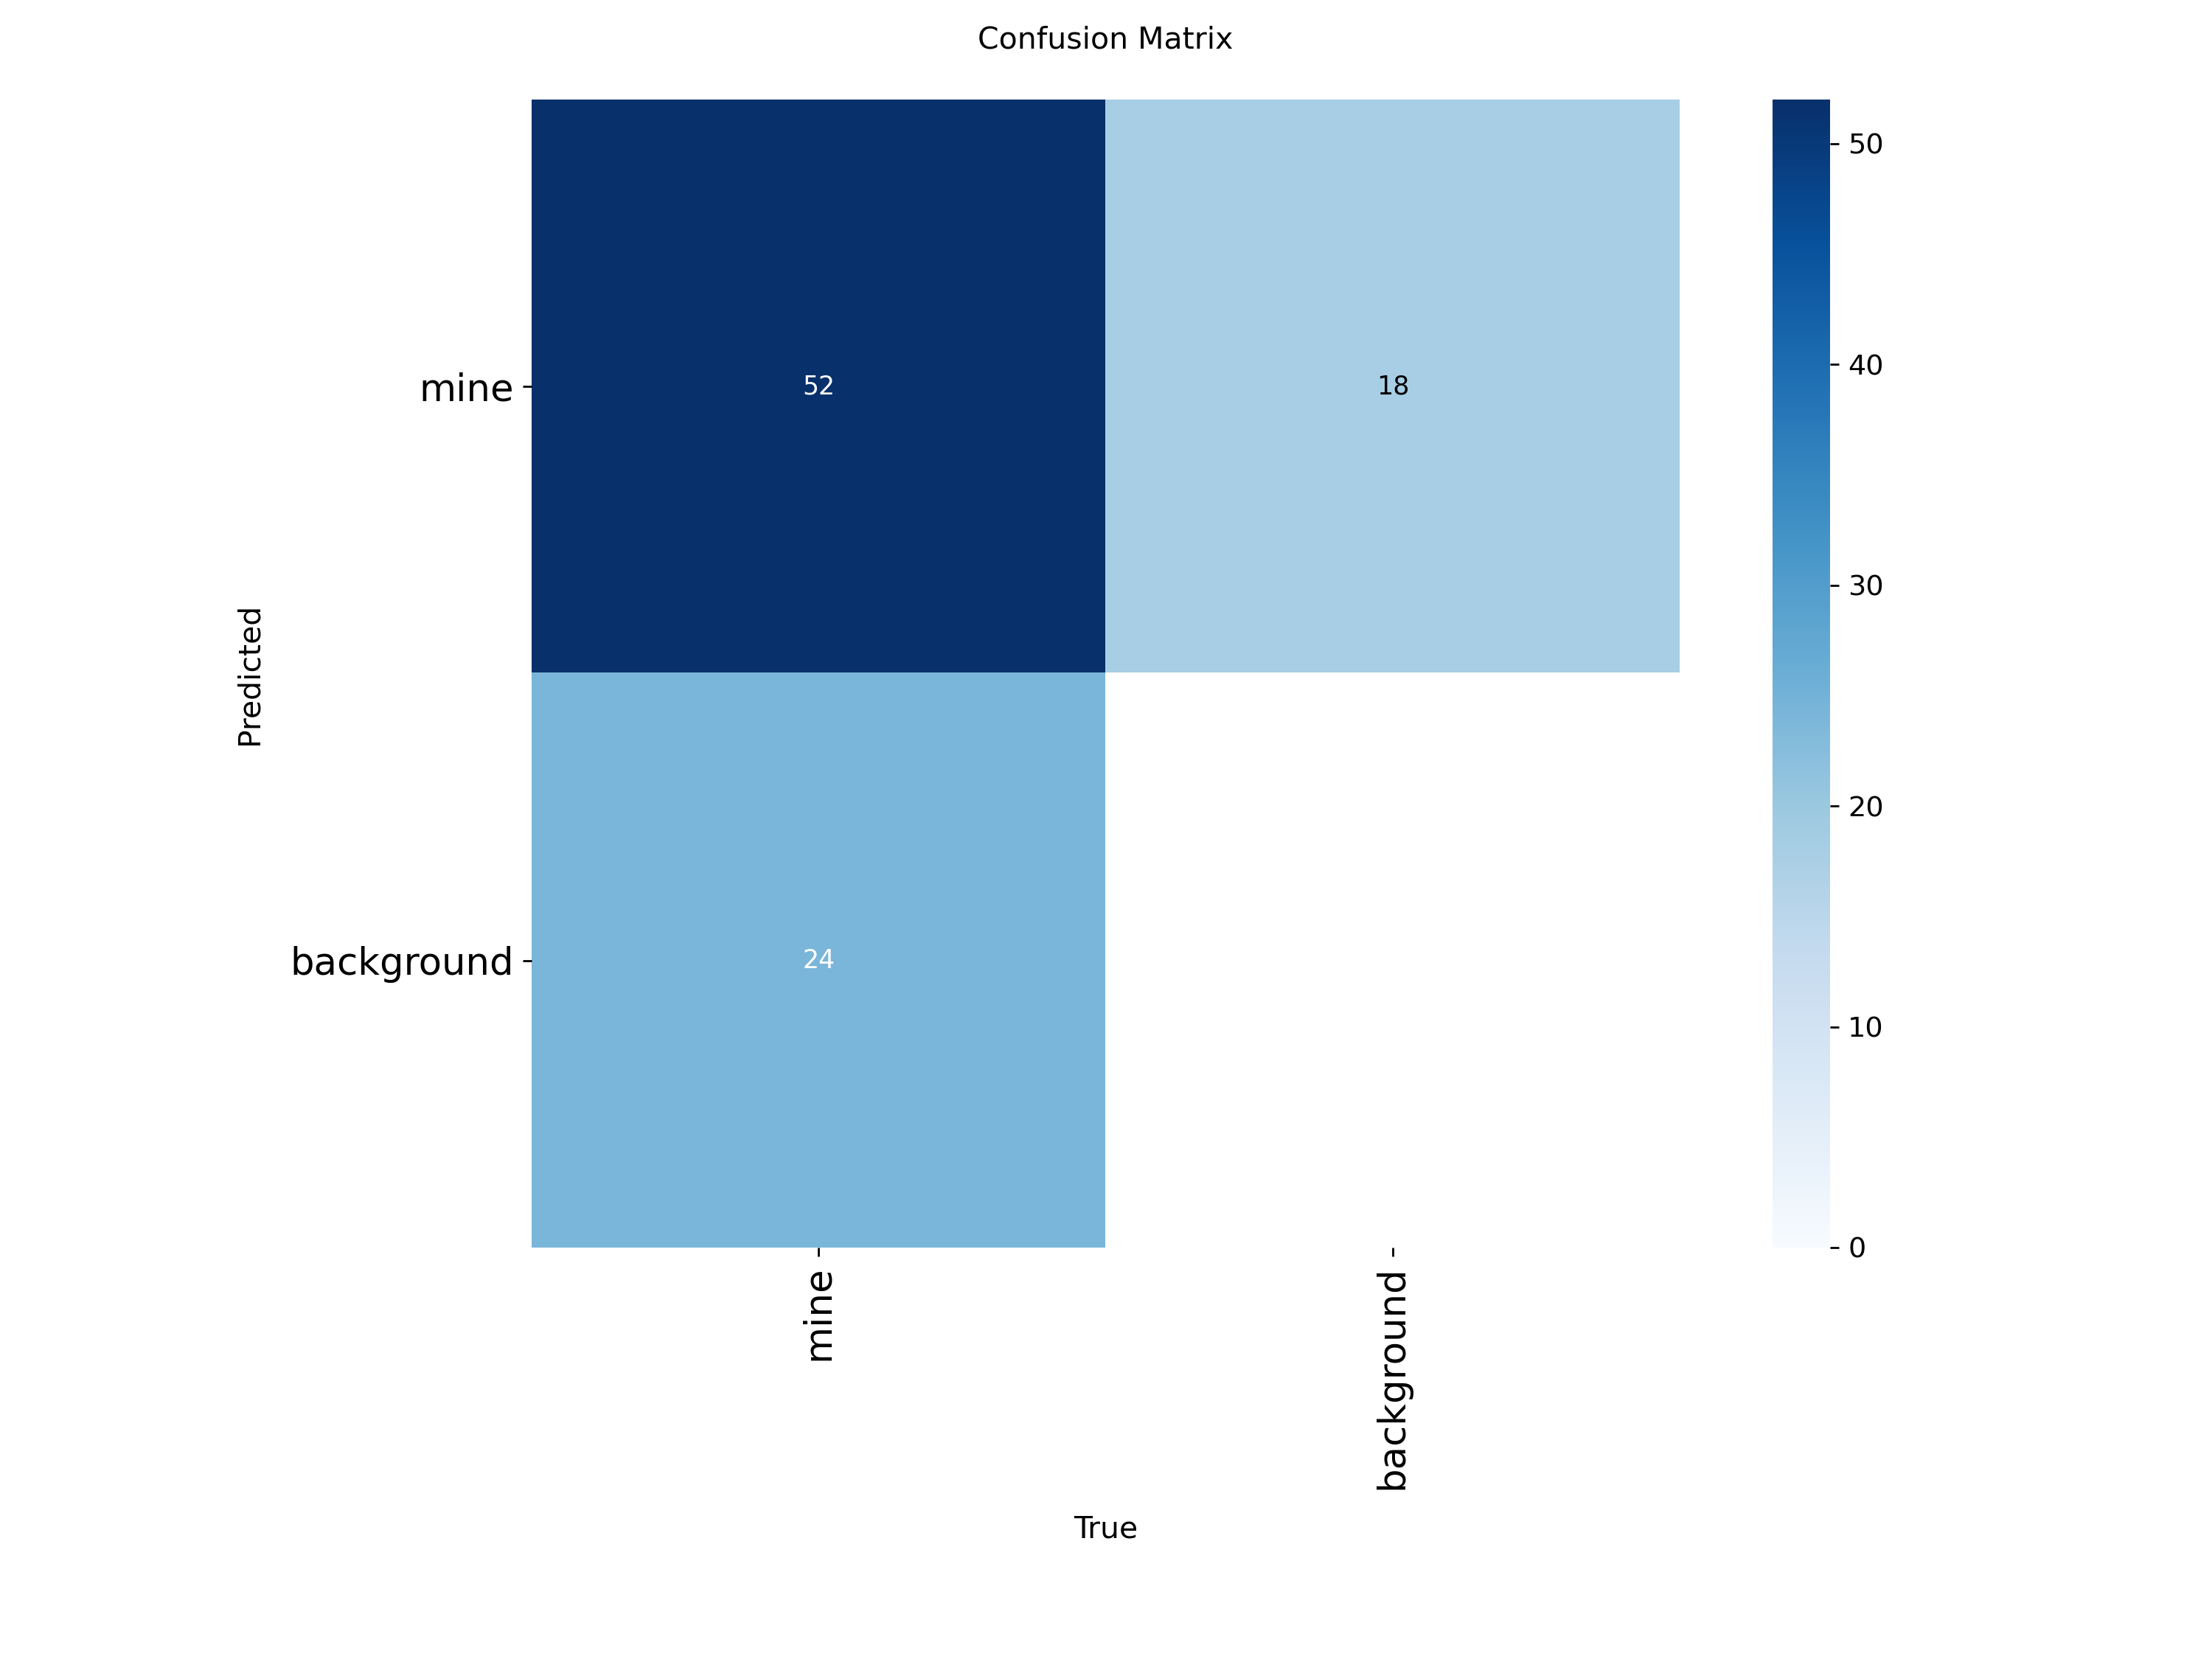

In [11]:
from IPython.display import Image, display

run1_dir = '/kaggle/working/runs/detect/mine_detection/run1-2'
display(Image(filename=f'{run1_dir}/confusion_matrix.png'))

## Run 2 — YOLO11m, sonar-domain-pretrained (SONARINTEL)

Loads a community-published model pretrained on side-scan sonar
imagery (5 classes: crab_pot, submarine_pipeline, shipwreck,
ghost_net, mine_like_contact). Training with `nc=1` causes Ultralytics
to discard/reinitialize only the final detection head — the backbone
and neck (general sonar feature extraction) carry over as the
starting point.

In [12]:
from huggingface_hub import hf_hub_download

weights_path = hf_hub_download(repo_id="Samyukta31/sonar_yolo", filename="best.pt")
model_run2 = YOLO(weights_path)

results_run2 = model_run2.train(
    data=DATA_YAML,
    imgsz=640,
    epochs=100,
    batch=16,
    patience=20,
    project='mine_detection',
    name='run2_sonar_pretrained',
    **AUGMENTATION_CONFIG,
)

best.pt:   0%|          | 0.00/161M [00:00<?, ?B/s]

Ultralytics 8.4.152 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=15, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.3, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/root/.cache/huggingface/hub/models--Samyukta31--sonar_yolo/snapshots/ea58dee2a27b6df4a5182217b3a7b0c75a64a3a4/best

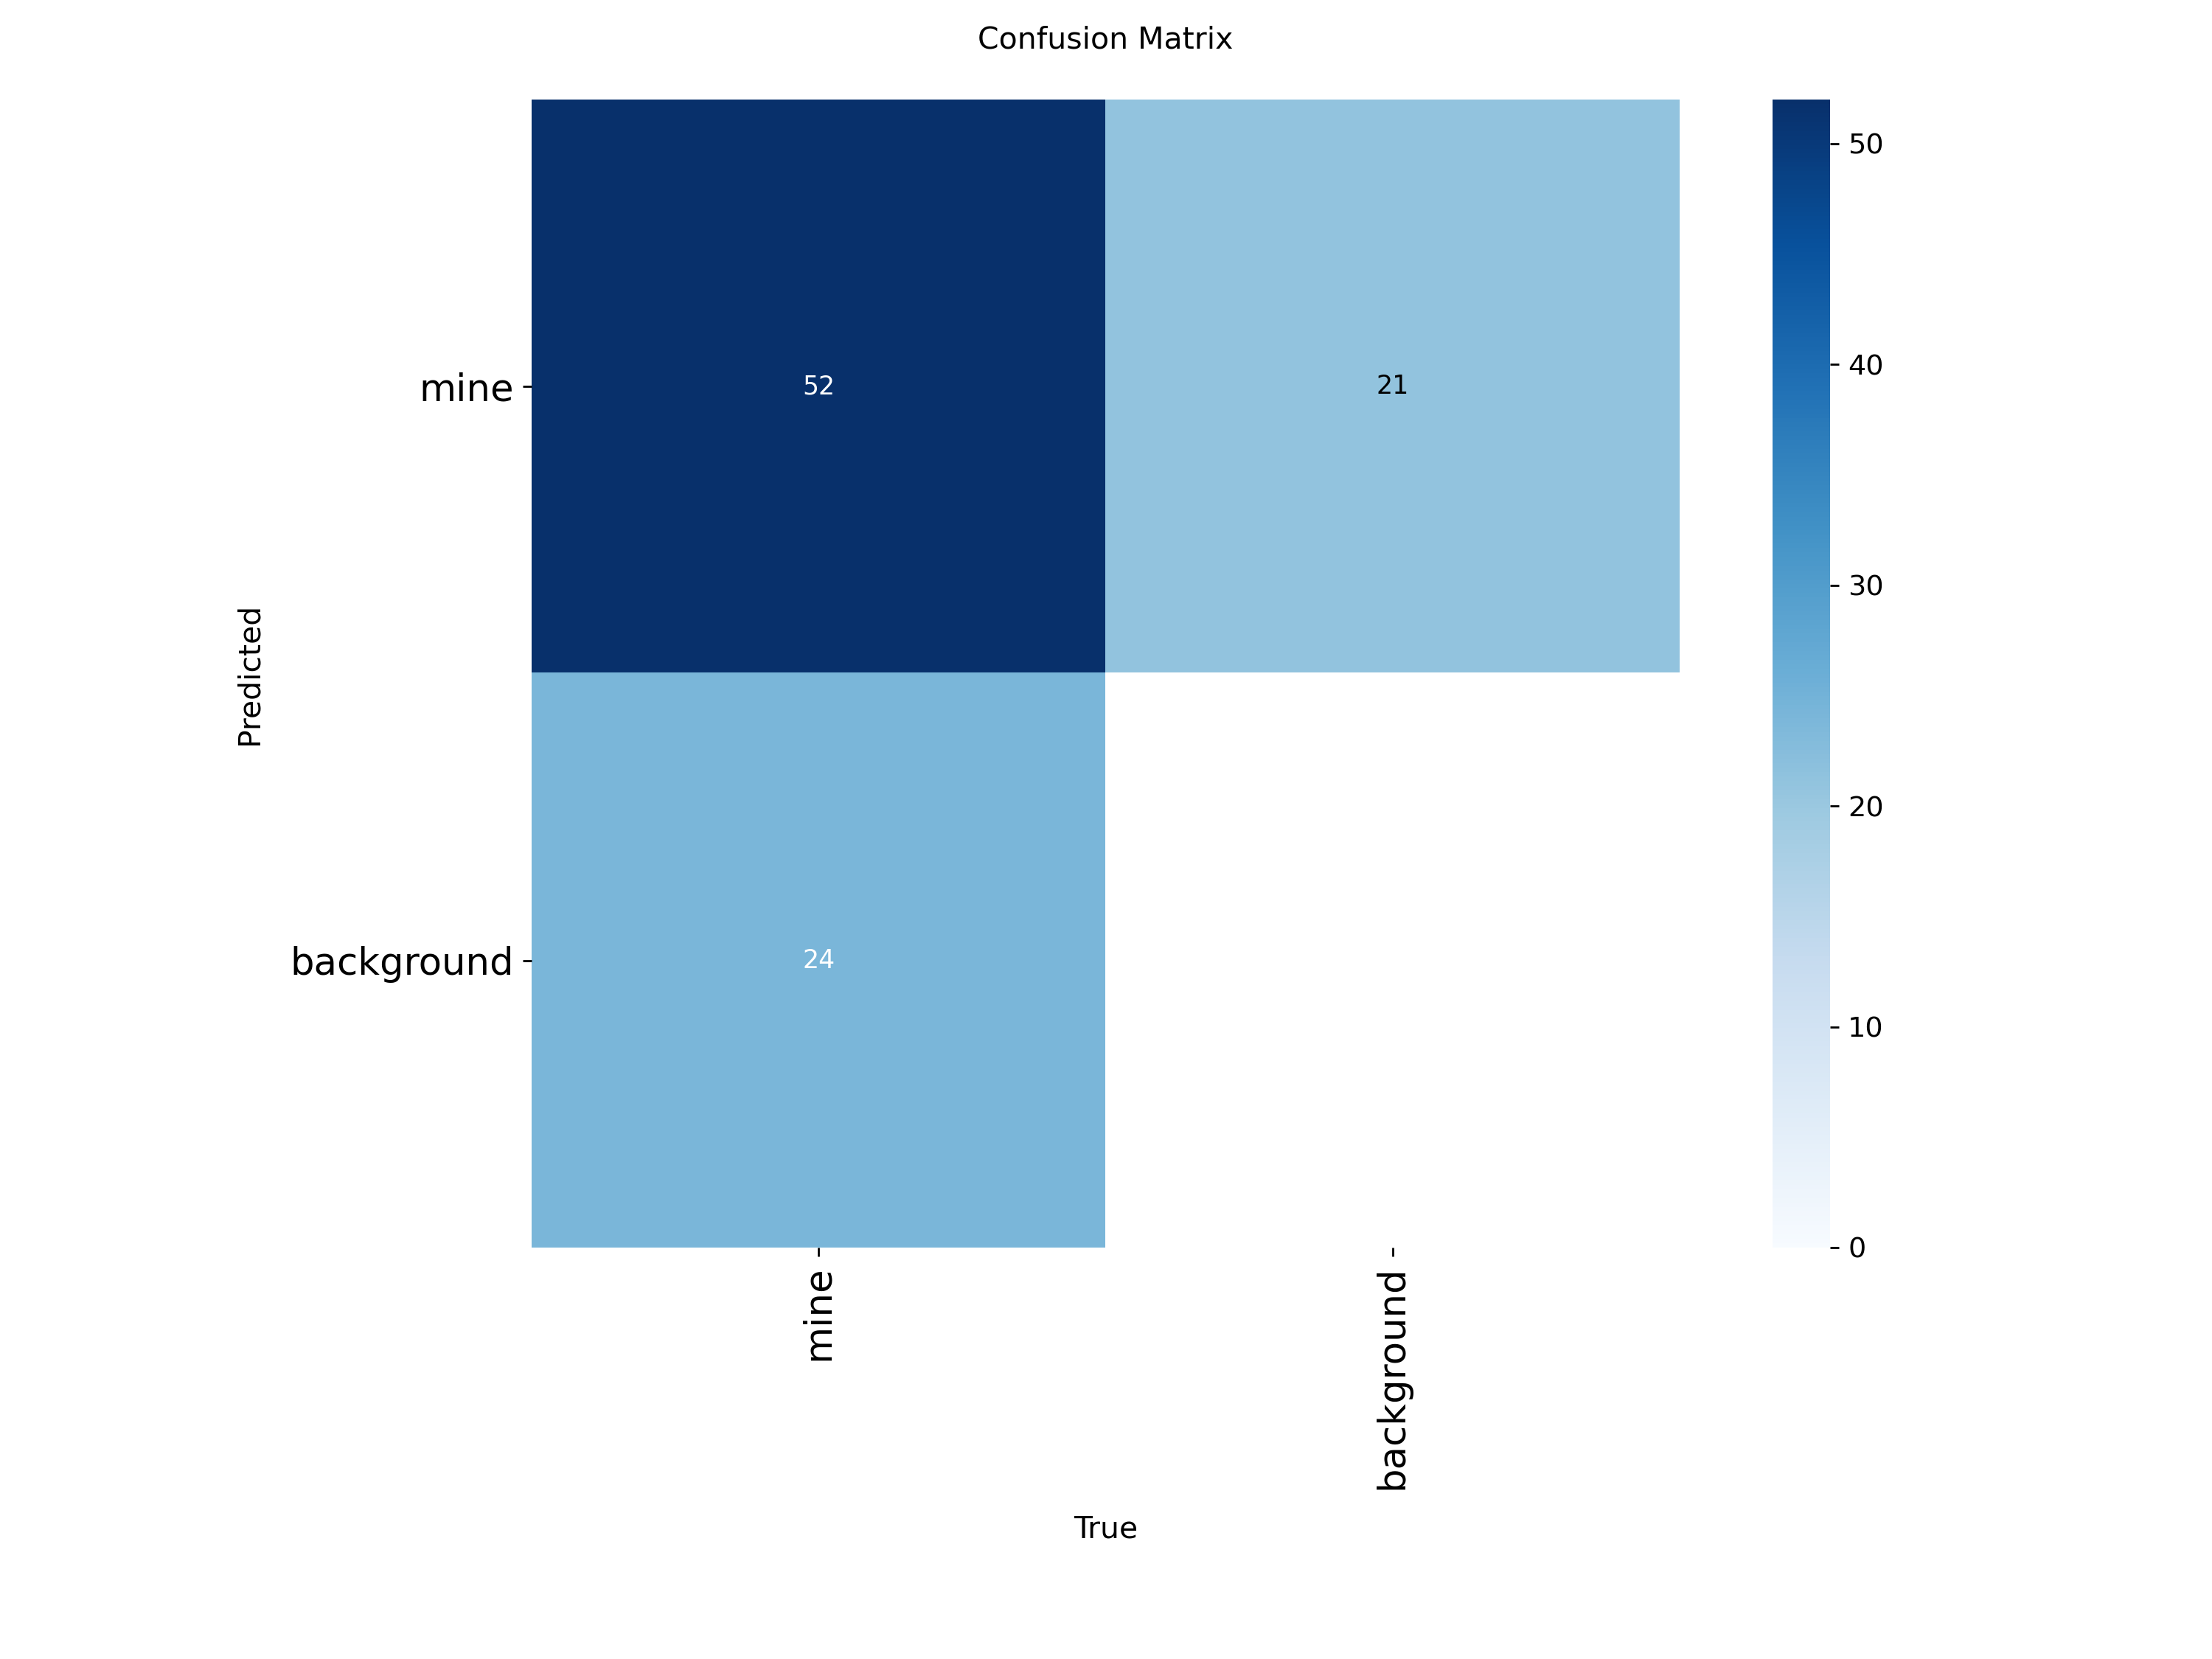

In [13]:
run2_dir = '/kaggle/working/runs/detect/mine_detection/run2_sonar_pretrained'
display(Image(filename=f'{run2_dir}/confusion_matrix.png'))

## Run 3 — YOLO11m, COCO-pretrained (size-matched control)

Isolates whether Run 2's result was driven by model size (YOLO11m's
larger capacity overfitting the small dataset) or by the
sonar-pretrained backbone itself — same architecture size as Run 2,
generic COCO pretraining instead.

In [14]:
model_run3 = YOLO('yolo11m.pt')

results_run3 = model_run3.train(
    data=DATA_YAML,
    imgsz=640,
    epochs=100,
    batch=16,
    patience=20,
    project='mine_detection',
    name='run3_coco_m',
    **AUGMENTATION_CONFIG,
)

Ultralytics 8.4.152 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=15, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.3, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=run3_coco_m, nbs=64, nms=None, opset=None, optimize=F

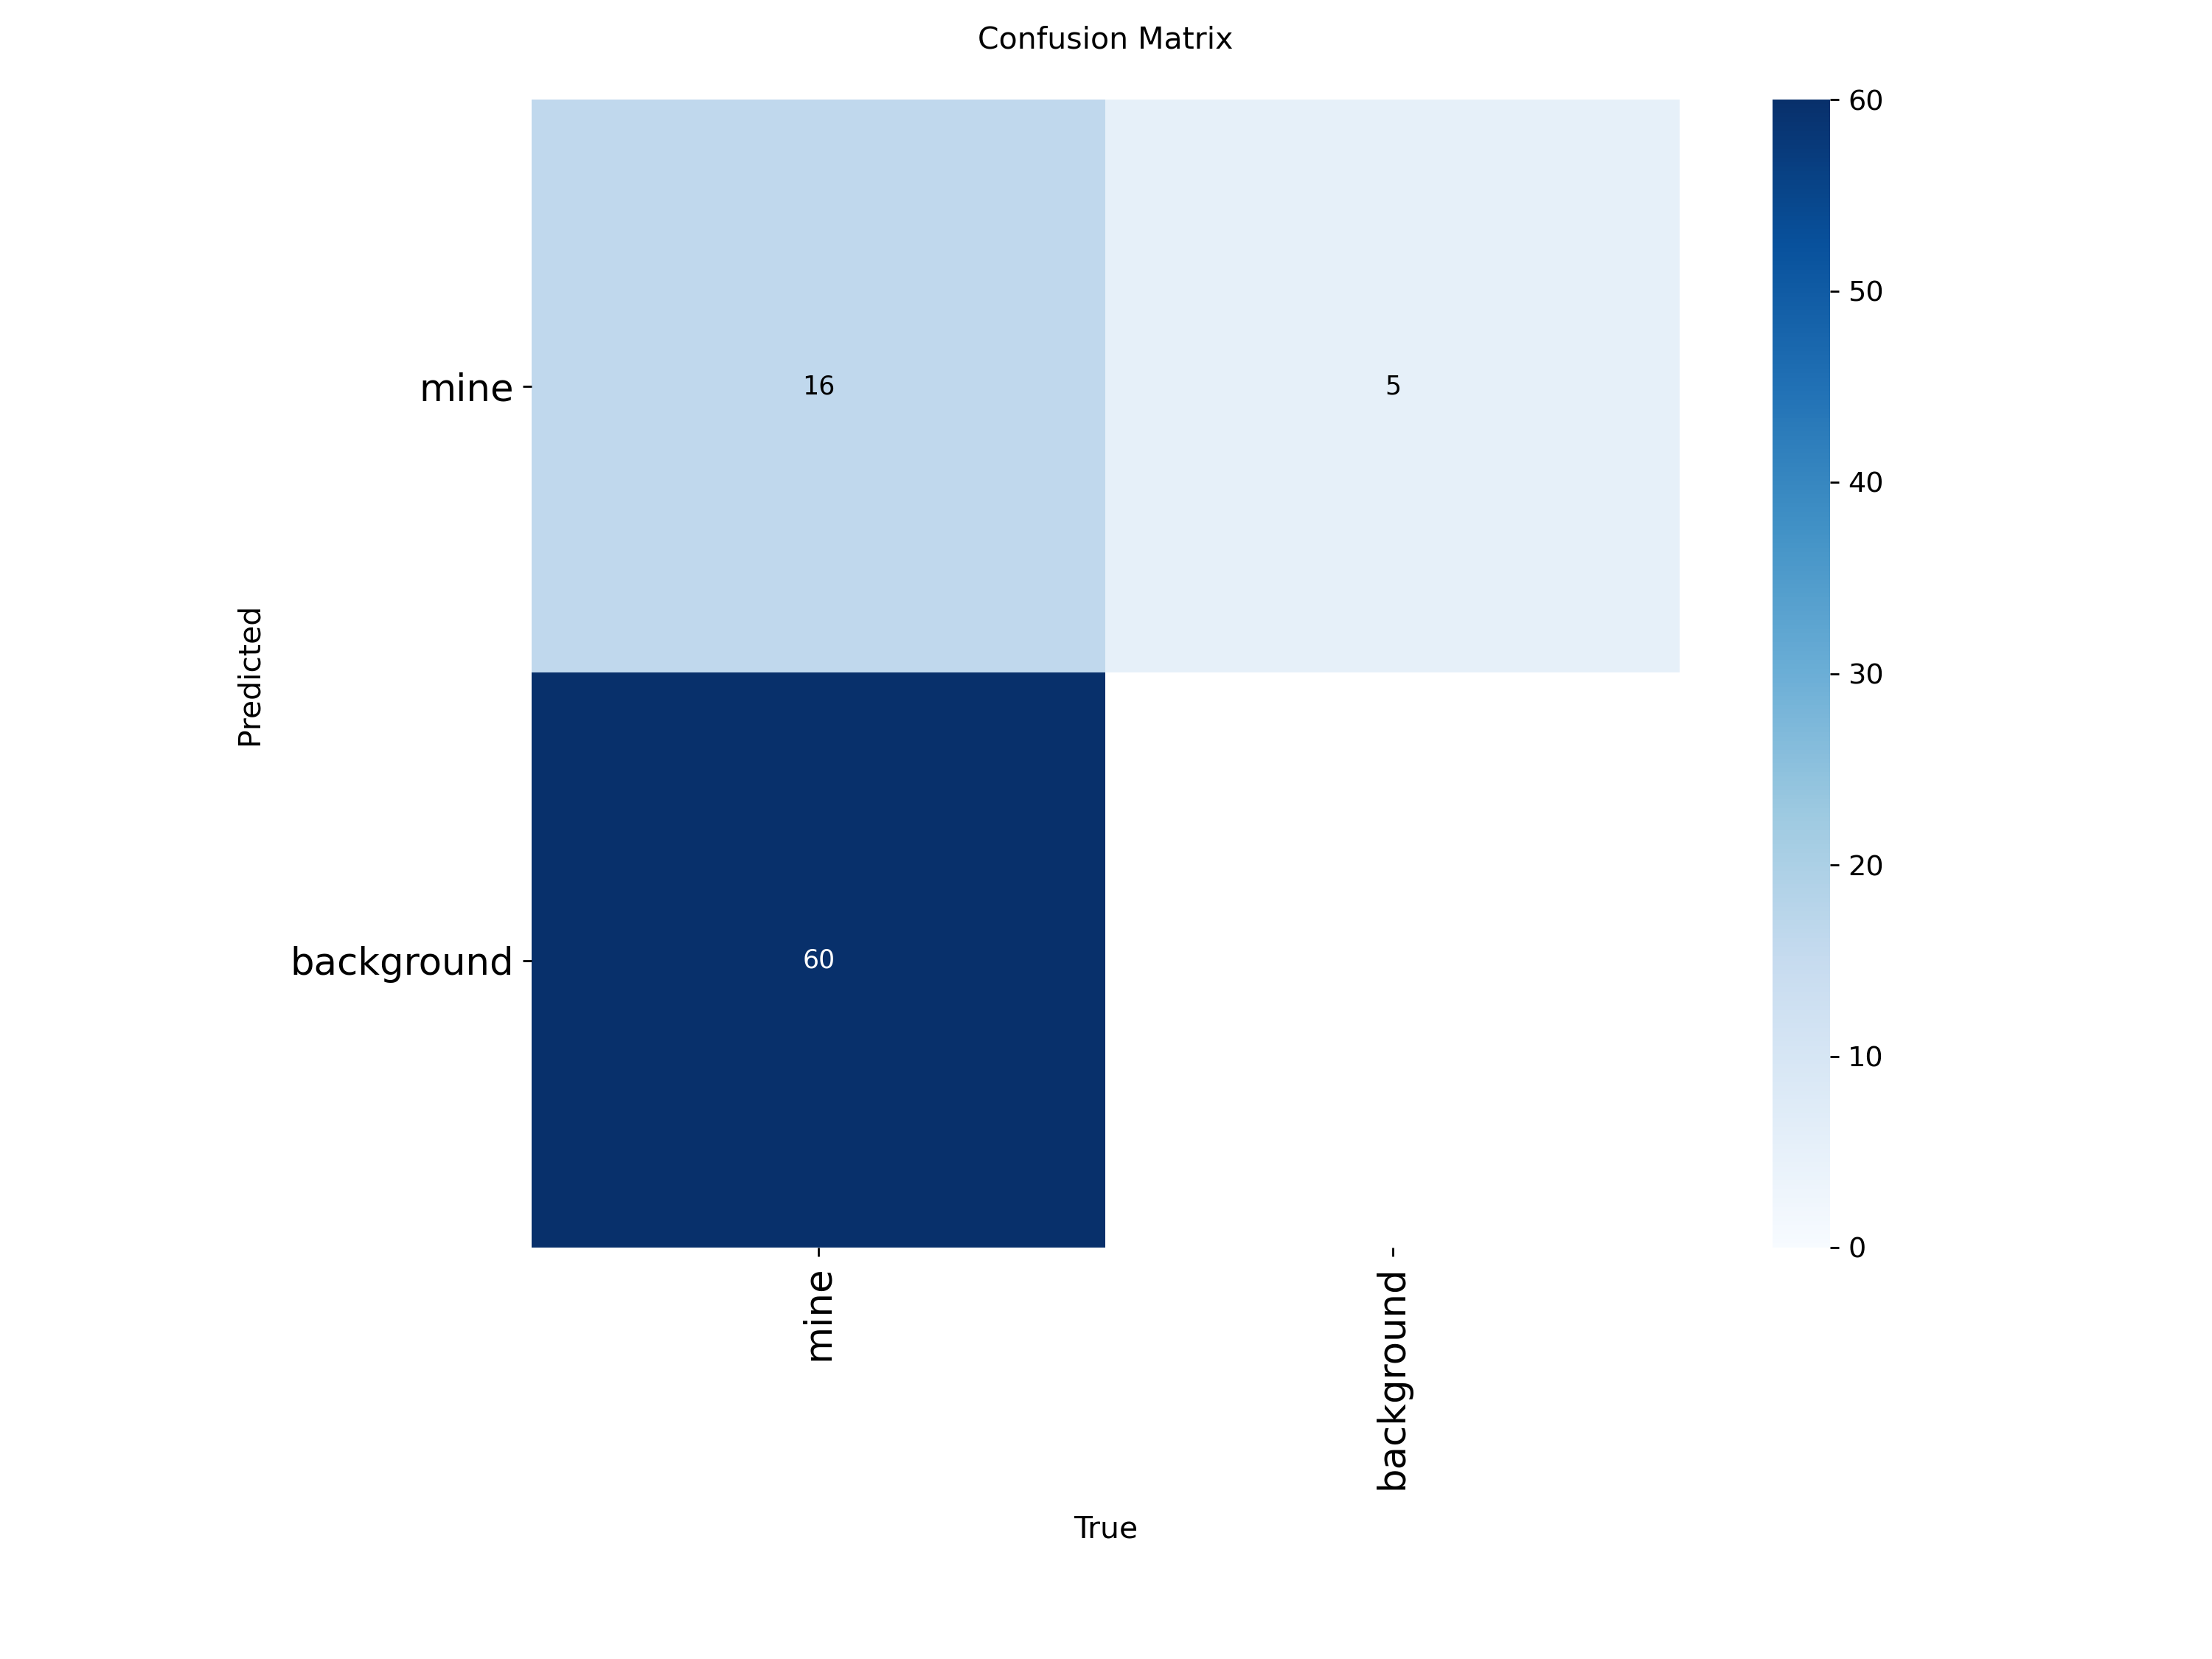

In [15]:
run3_dir = '/kaggle/working/runs/detect/mine_detection/run3_coco_m'
display(Image(filename=f'{run3_dir}/confusion_matrix.png'))



# Evaluation & Comparison


Run 1 (COCO, YOLO11n)


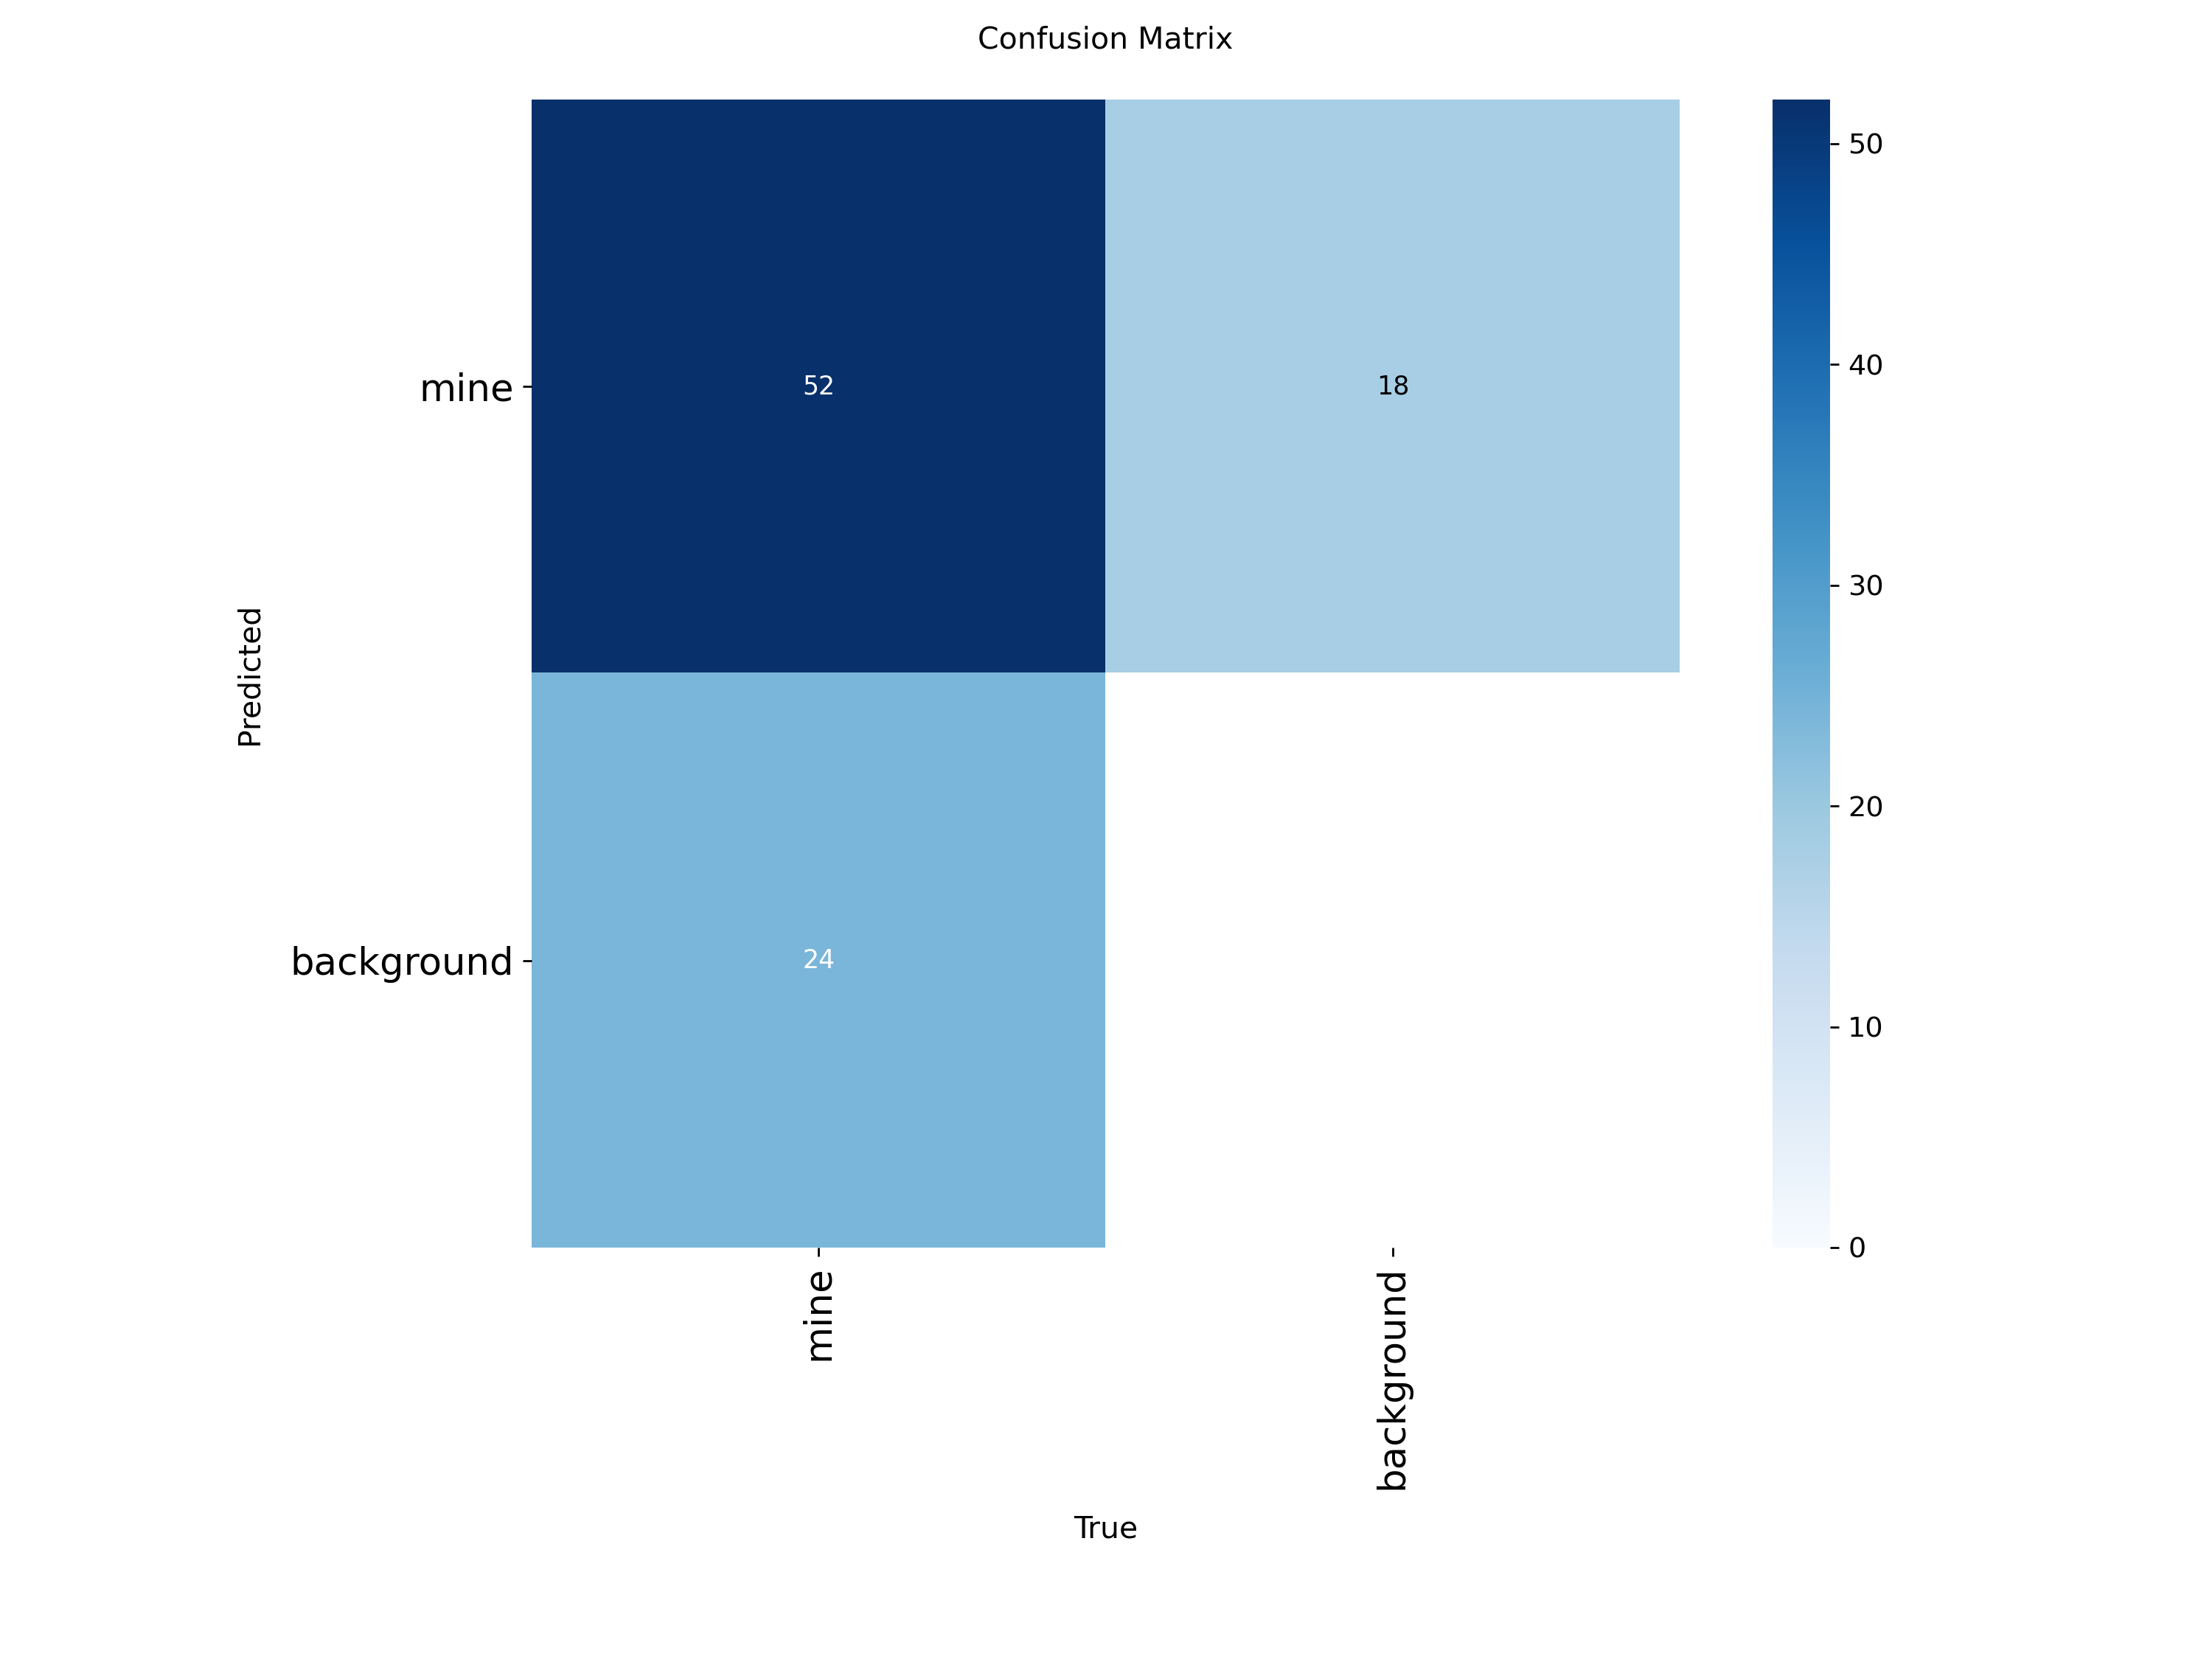

Run 2 (Sonar-pretrained, YOLO11m)


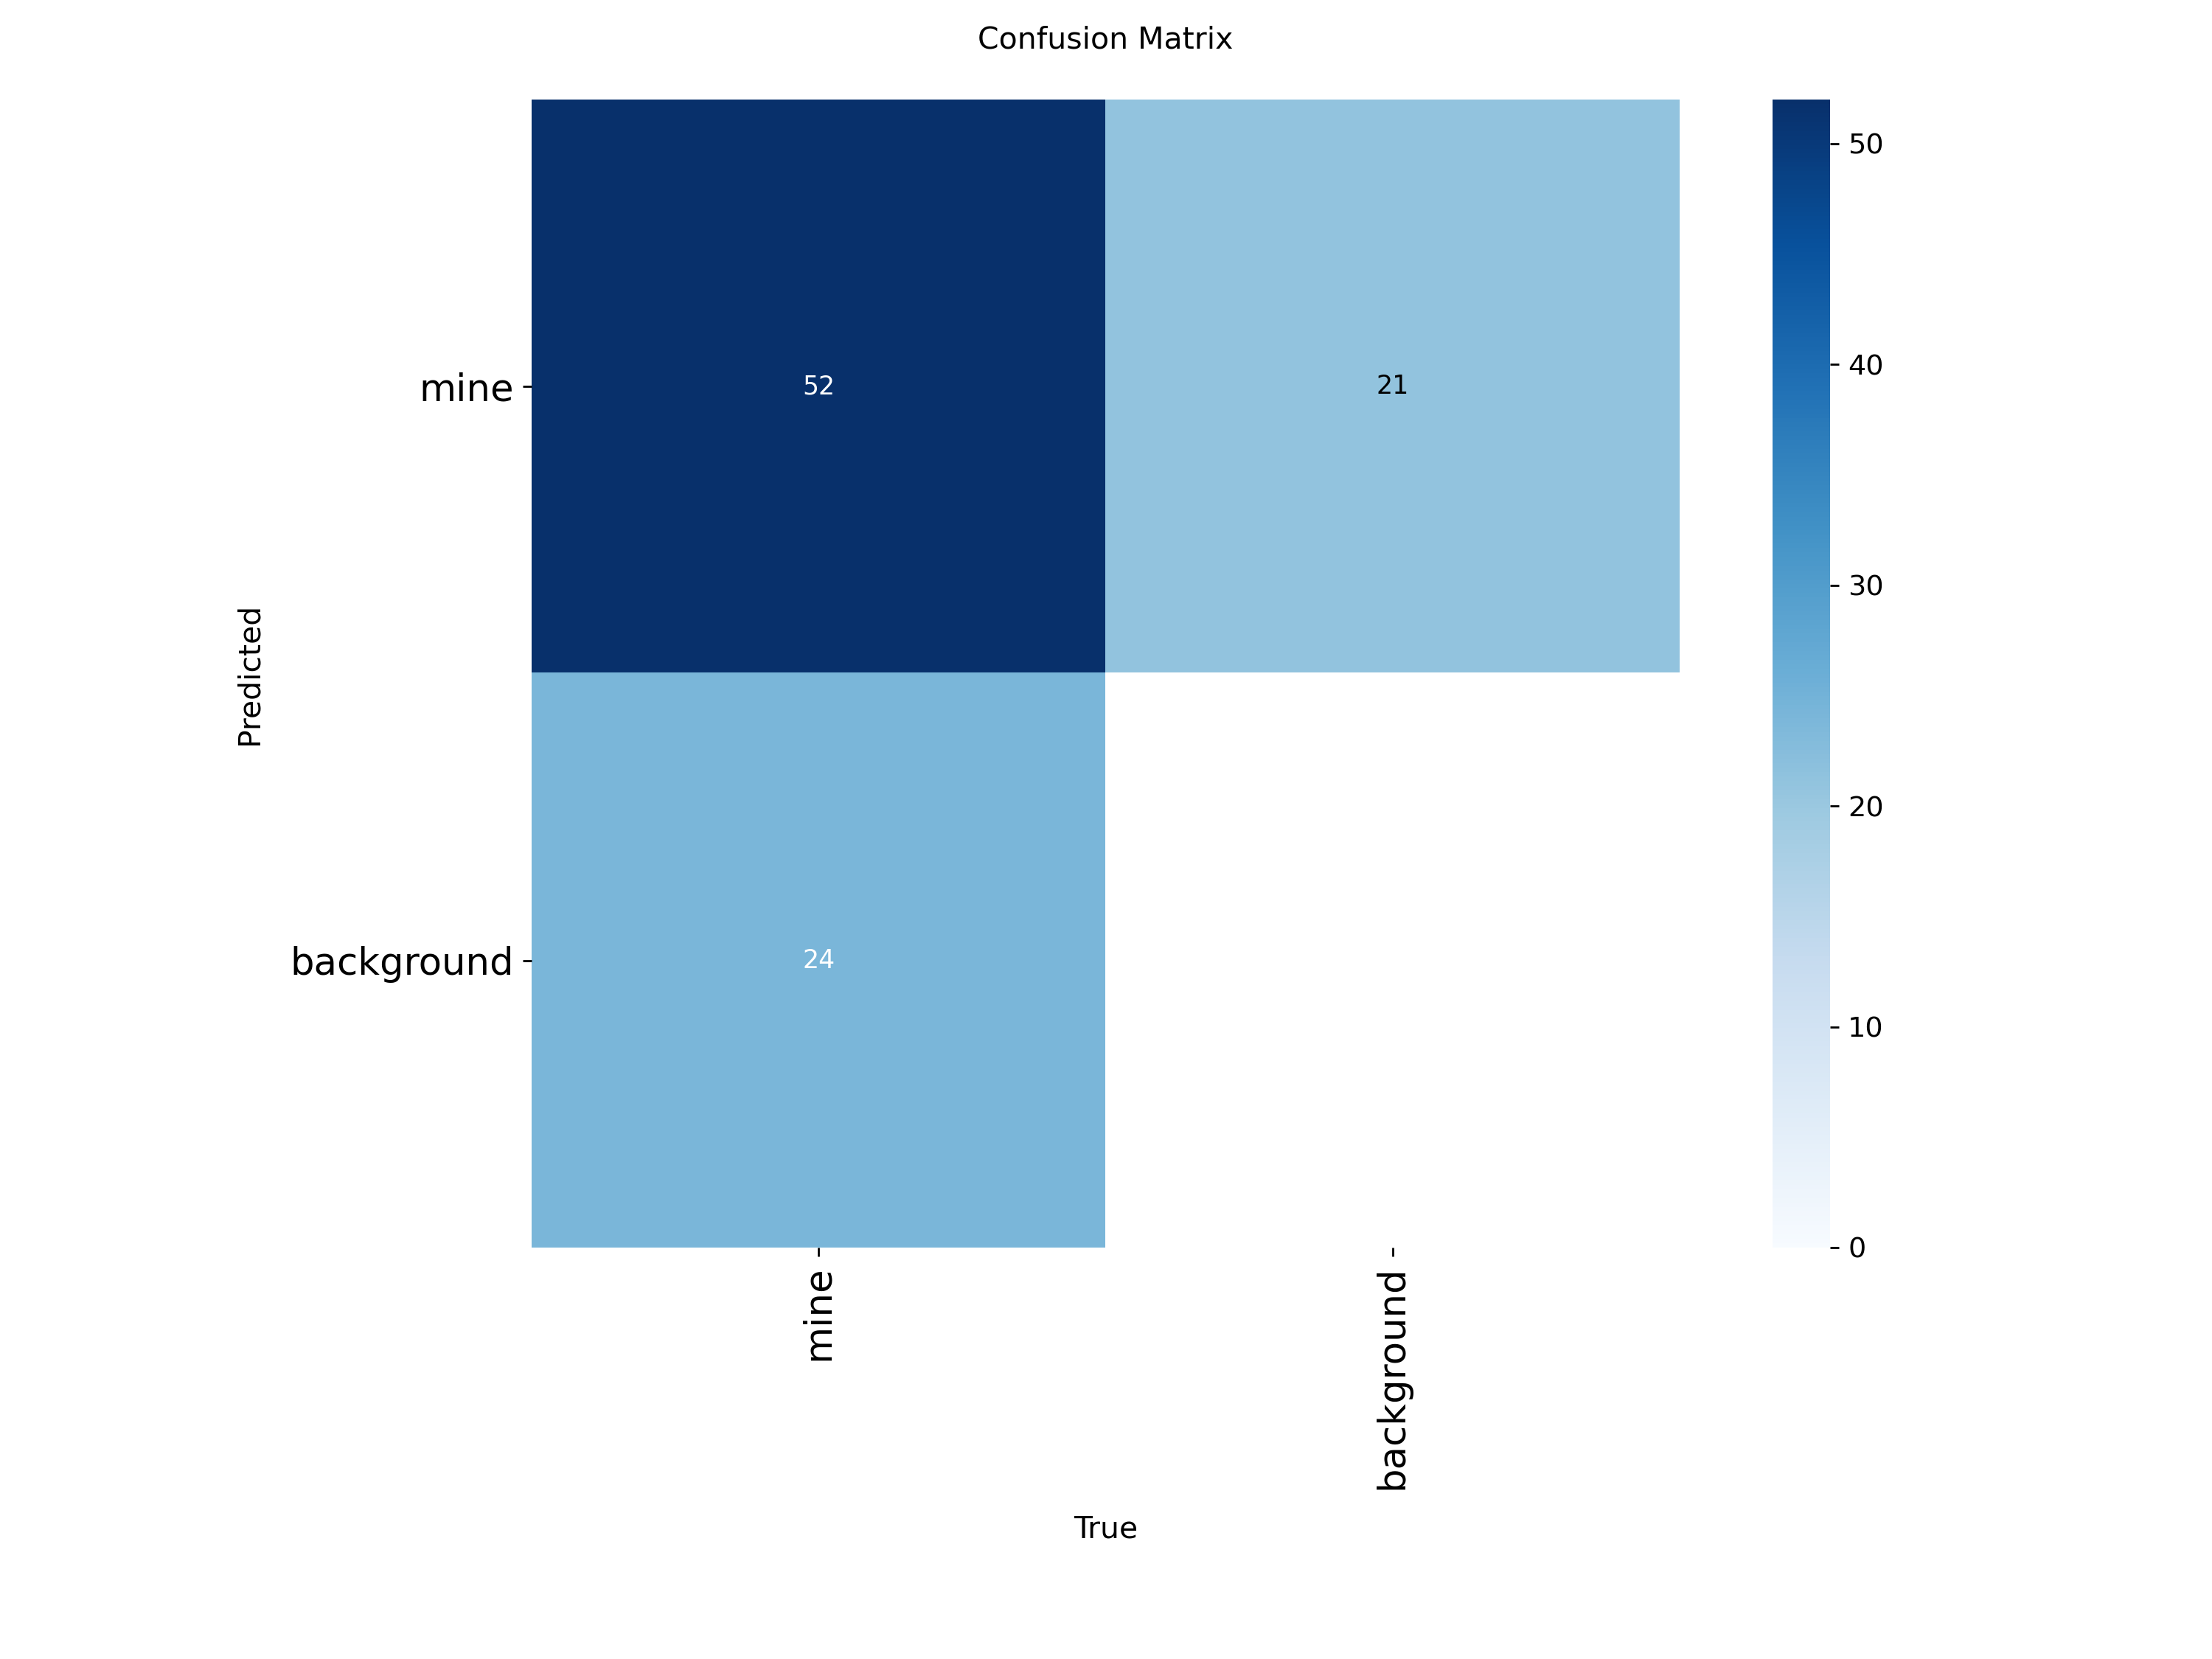

Run 3 (COCO, YOLO11m)


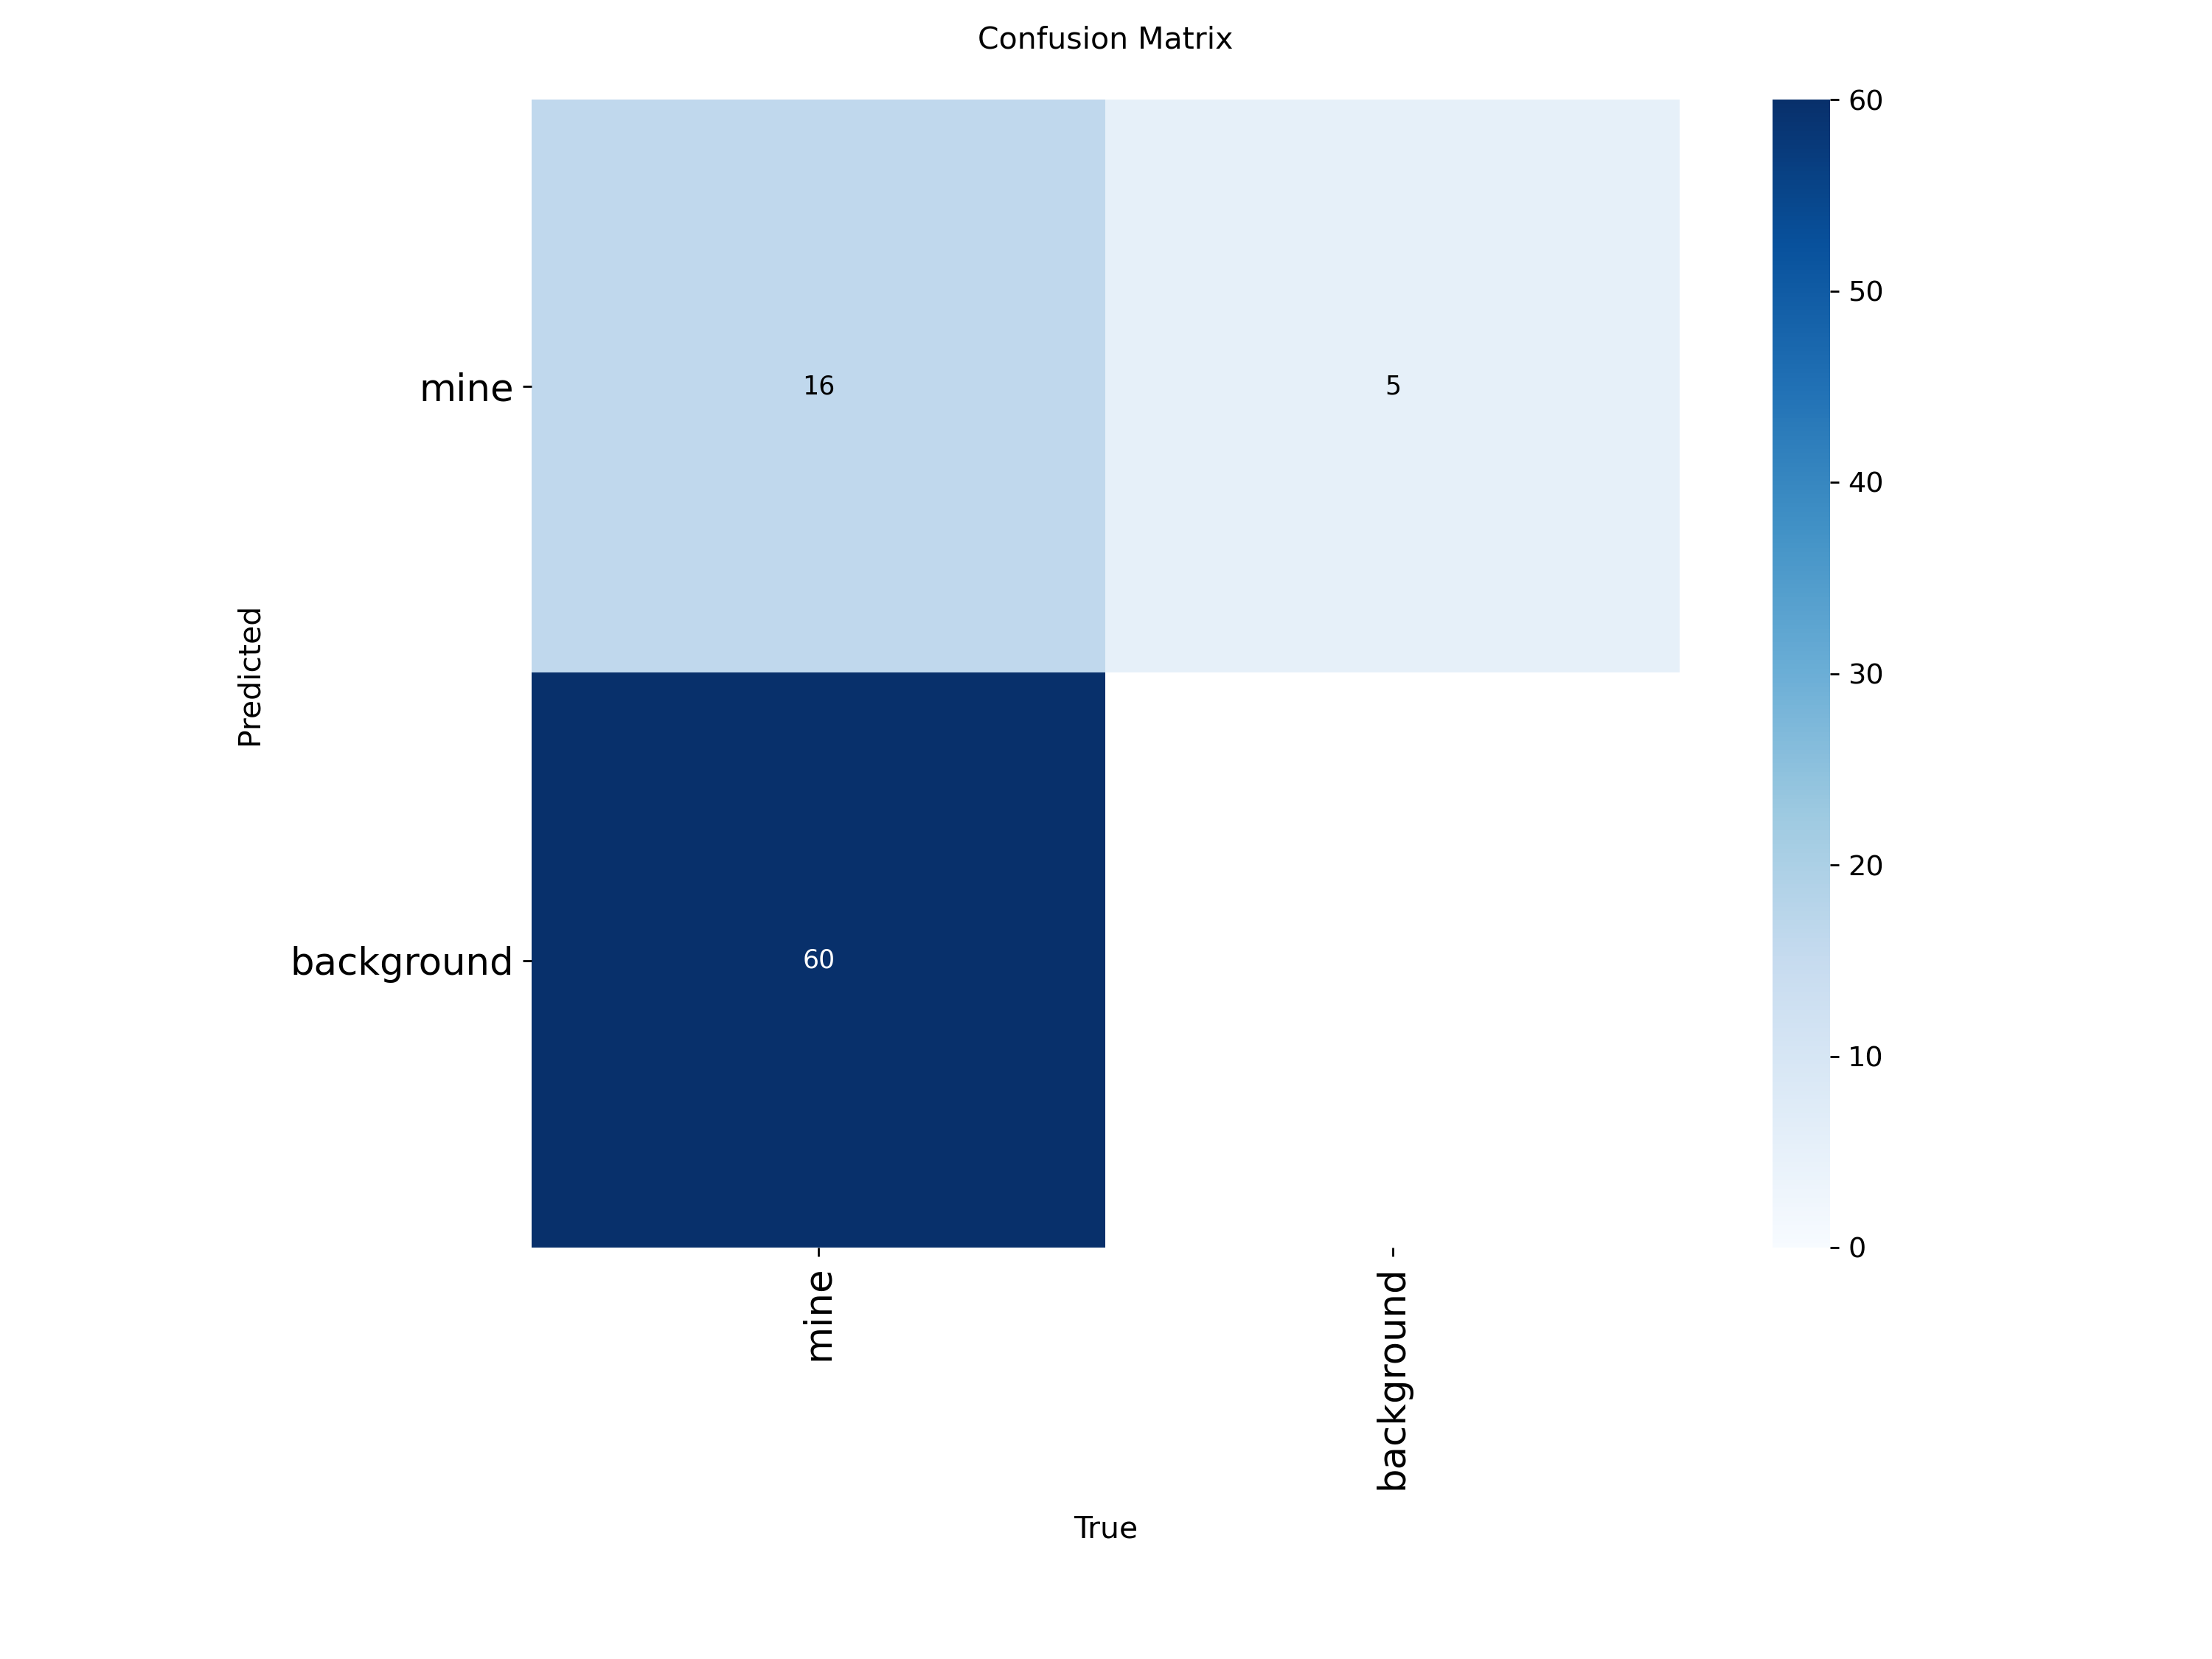

In [16]:
from IPython.display import Image, display

runs = {
    'Run 1 (COCO, YOLO11n)': '/kaggle/working/runs/detect/mine_detection/run1-2',
    'Run 2 (Sonar-pretrained, YOLO11m)': '/kaggle/working/runs/detect/mine_detection/run2_sonar_pretrained',
    'Run 3 (COCO, YOLO11m)': '/kaggle/working/runs/detect/mine_detection/run3_coco_m',
}

for name, path in runs.items():
    print(name)
    display(Image(filename=f'{path}/confusion_matrix.png'))

## Ground truth vs. prediction — visual inspection

Draws ground-truth boxes (parsed directly from the label file, green)
alongside the best model's (Run 1) predicted boxes, for direct visual
comparison on a chosen validation image.


image 1/1 /kaggle/input/datasets/tarunpandianm/umd-ssd/merged_dataset/images/val/0016_2015.jpg: 640x640 2 mines, 8.0ms
Speed: 1.8ms preprocess, 8.0ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


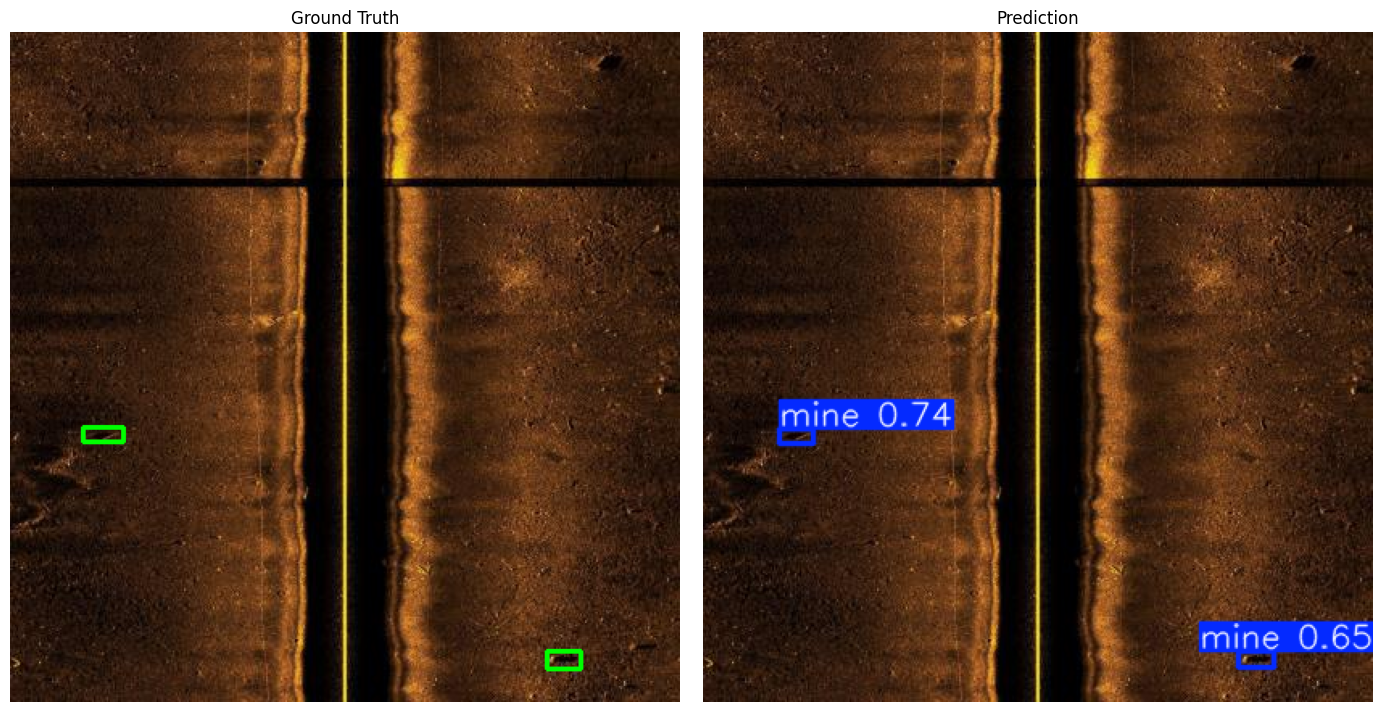

In [20]:
model = YOLO('/kaggle/working/runs/detect/mine_detection/run1-2/weights/best.pt')
#model = YOLO('/kaggle/working/runs/detect/mine_detection/run2_sonar_pretrained/weights/best.pt')
#model = YOLO('/kaggle/working/runs/detect/mine_detection/run3_coco_m/weights/best.pt')


img_path = '' # datasetpath within ''   
label_path = img_path.replace('/images/', '/labels/').replace('.jpg', '.txt')

# ground truth
img_gt = cv2.imread(img_path)
h, w = img_gt.shape[:2]

with open(label_path, 'r') as f:
    for line in f.read().strip().splitlines():
        cls, xc, yc, bw, bh = map(float, line.split())
        x1 = int((xc - bw/2) * w)
        y1 = int((yc - bh/2) * h)
        x2 = int((xc + bw/2) * w)
        y2 = int((yc + bh/2) * h)
        cv2.rectangle(img_gt, (x1, y1), (x2, y2), (0, 255, 0), 2)

# prediction
results = model.predict(source=img_path, imgsz=640, conf=0.25)
img_pred = results[0].plot()

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(cv2.cvtColor(img_gt, cv2.COLOR_BGR2RGB))
axes[0].set_title('Ground Truth')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(img_pred, cv2.COLOR_BGR2RGB))
axes[1].set_title('Prediction')
axes[1].axis('off')

plt.tight_layout()
plt.show()